<a href="https://colab.research.google.com/github/rafaelromwno/am-t4-s1a2026/blob/main/aula-8/NeuralizadorCensus0424.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Pipeline | Carregamento [Fase 1 - base_census]

## Importar dados do Google Drive

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [27]:
!pip -q install plotly
!pip -q install yellowbrick

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as pl
import plotly.express as px

## Carregar Digest de base_credit

In [29]:
import pickle

In [30]:
with open('/content/drive/MyDrive/Documentos/profissional-academico/FATEC/CICLOS/ciclo-v/machine-learning/census.pkt', mode = 'rb') as f:
   X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [31]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [32]:
X_census_teste.shape,  Y_census_teste.shape

((4885, 108), (4885,))

In [33]:
from sklearn.naive_bayes import GaussianNB

In [34]:
# cria o modelo Naive Bayes Gaussiano
naive_credit_data = GaussianNB()

# treina o modelo com os dados de treinamento (features e rótulos)
naive_credit_data.fit(X_census_treinamento, Y_census_treinamento)

GaussianNB()

## Criando base previsora

In [35]:
census_predict = naive_credit_data.predict(X_census_teste)

In [36]:
census_predict

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      dtype='<U6')

In [37]:
 Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [39]:
accuracy_score( Y_census_teste, census_predict)

0.4767656090071648

In [40]:
confusion_matrix( Y_census_teste, census_predict)

array([[1172, 2521],
       [  35, 1157]])

In [41]:
from yellowbrick.classifier import ConfusionMatrix

0.4767656090071648

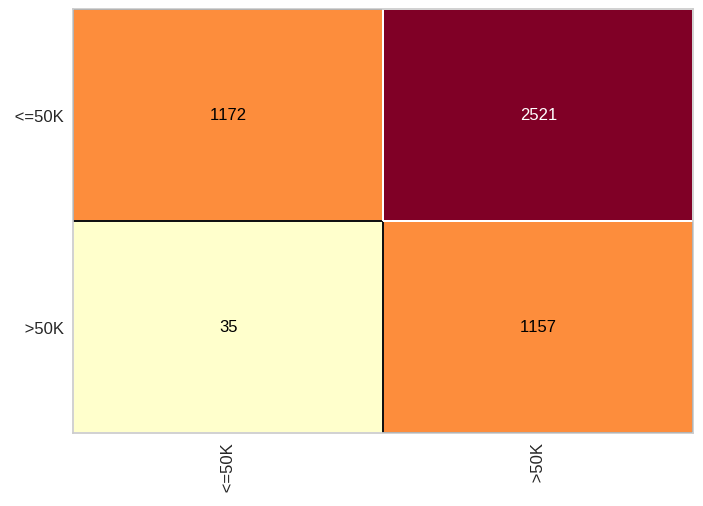

In [42]:
cm_credit = ConfusionMatrix(naive_credit_data)
cm_credit.fit(X_census_treinamento, Y_census_treinamento)
cm_credit.score(X_census_teste,  Y_census_teste)